<a href="https://github.com/PDBeurope/pdbe-notebooks/blob/eccb_tutorial/eccb_2026/structure_bioactivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BioChemGraph Training Material**

## Overview
The BioChemGraph project combines data from three important resources: the Protein Data Bank (PDB), the ChEMBL database, and the Cambridge Structural Database (CSD). This integrated data provides researchers with structural, functional, and biochemical annotations for small molecules and their targets, which can be used to better understand their roles in biological processes and aid in drug discovery.

<p>
    <img src="https://drive.google.com/uc?export=view&id=1gkAvDbDe3QVnuHER0bNXRK_m4OA0jkH6" width="400" style="float:right; margin-left:15px;"/>
    </p>

This tutorial will guide users through analysing integrated small molecule data from ChEMBL, PDBe, and CCDC resources and will focus on integrating data from multiple bioinformatics resources to address complex questions in drug discovery and molecular interactions

## Use case: Tyrosine-protein kinase ABL1 and inhibitors
Tyrosine-protein kinase ABL1 (UniProt P00519) is a crucial enzyme involved in many cellular processes, including cell growth, division, and response to stress.  However, a genetic abnormality can create a fusion gene, BCR-ABL1, which produces an overactive ABL1 protein. This abnormal activity drives the development of chronic myeloid leukemia (CML). Thankfully, scientists have developed tyrosine kinase inhibitors (TKIs) like imatinib and nilotinib. These drugs specifically target and block the activity of the BCR-ABL1 protein, effectively treating CML and significantly improving patient outcomes.  Despite their success, resistance to these inhibitors can emerge, prompting ongoing research into new therapies and strategies to overcome drug resistance.



  ## Instructions <a name="Instructions"></a>

* Quick Start <a name="Quick Start"></a>

In order to make the learning experience more accessible and interactive, we have incorporated widgets that allow you to provide inputs and customize certain aspects of the code. These widgets serve as interactive elements that enhance your ability to interact with the code and observe the impact of different inputs on the results. Throughout this tutorial, you will come across code chunks that include these interactive widgets.

  * How to use Google Colab <a name="Google Colab"></a>
1. To run a code cell, click on the cell to select it. You will notice a play button (▶) on the left side of the cell. Click on the play button or press Shift+Enter to run the code in the selected cell.
2. The code will start executing, and you will see the output, if any, displayed below the code cell.
3. Move to the next code cell and repeat steps 2 and 3 until you have executed all the desired code cells in sequence.
4. The currently running step is indicated by a circle with a stop sign next to it.
If you need to stop or interrupt the execution of a code cell, you can click on the stop button (■) located next to the play button.

*Remember to run the code cells in the correct order, as their execution might depend on variables or functions defined in previous cells. You can modify the code in a code cell and re-run it to see updated results.*

## Contact us

Requests for clarifications or reporting bugs can be made via pdbehelp@ebi.ac.uk.

## Part 1: Parsing Bioactivity Data
#### **Goal:** Read and Parse bioactivity data reports obtained via PDBe FTP (to be released in October)

The files can be dowloaded from here (add link).

#### Tasks:
1. Extract relevant bioactivity data for the kinase + inhibitor use case. Consider both ABL and BCR-ABL targets.
2. Visualization: Generate a heatmap to display bioactivity data (targets vs. drugs). This will help identify key patterns and insights.
3. Comparison: Identify an example where a drug demonstrates higher binding affinity to one target over another.



### Setup

In [ ]:
#import needed packages
import pandas as pd
pd.options.mode.chained_assignment = None  # Suppress pandas warnings
pd.set_option('display.max_colwidth', None) # Allows full column view
from google.colab import data_table
import seaborn as sns
import matplotlib.pyplot as plt
import ftplib
from io import BytesIO


### Parsing datasets

In [ ]:
#Get data from FTP and read dataframe with pandas
def read_dataframe_from_ftp(ftp_url, filename, username, password):
  """
  Reads a dataframe from a file on an FTP server.

  Args:
    ftp_url: The URL of the FTP server.
    filename: The name of the file on the FTP server.
    username: The username for the FTP server. Usually anonynous
    password: The password for the FTP server. Usually anonymous
    **kwargs: Additional keyword arguments to pass to pandas.read_csv.

  Returns:
    A pandas DataFrame.
  """
  try:
    # Connect to the FTP server
    ftp = ftplib.FTP(ftp_url)
    ftp.login(username, password)

    # Create a BytesIO object to store the file data
    flo = BytesIO()

    # Retrieve the file from the FTP server
    ftp.retrbinary('RETR ' + filename, flo.write)
    flo.seek(0)

    # Read the file into a pandas DataFrame
    df = pd.read_csv(flo, sep='\t')

    # Close the FTP connection
    ftp.quit()

    return df

  except Exception as e:
    print(f"Error reading dataframe from FTP: {e}")
    return None

ftp_url = "ftp.ebi.ac.uk"
filename = "biochem"
username = "anonymous"
password = "anonymous@domain.com"

report = read_dataframe_from_ftp(ftp_url, filename, username, password)

Error reading dataframe from FTP: 550 Failed to open file.


In [ ]:
if report is not None:
    print(report.head())  # Print the first few rows of the dataframe

In [ ]:
report[report.CHEMBL_ID_MOL == 'CHEMBL1171837']

AttributeError: 'NoneType' object has no attribute 'CHEMBL_ID_MOL'

In [ ]:
'''Optional: If you want to load your own copy of report instead of downloading the file from FTP'''
#Read dataframe from imported file (alternative if file was locally downloaded **Files must be uploaded to the google colab session)

#report = pd.read_csv('/content/bioactivity_report_simple.tsv', sep='\t')

'Optional: If you want to load your own copy of report instead of downloading the file from FTP'

### Filtering data

The simple report shows an aggregated view of bioactivity data for unique complexes. The representative value is calculated as:

  - Mean pchembl
  - Mean inhibition %
  - No pchembl/other assays

To be able to compare the data we have to focus in just one data type. In this case mean pchembl seems the best option as it offers the most

In [ ]:
# Filtering main dataset
report_filtered = report[report['REP_TYPE'] == 'pchembl mean'] #Filter data to only plot complexes having a pchembl value mean
report_filtered.loc[:, 'PDB_BMID_CHAIN'] = report_filtered['PDB'] + ':' + report_filtered['BMID'].astype(str) + ':' + report_filtered['CHAIN'] # Create a new column combining PDB, BMID, and CHAIN

# Convert VALUE_REP to numeric, replacing non-convertible values with NaN
report_filtered['VALUE_REP'] = pd.to_numeric(report_filtered['VALUE_REP'], errors='coerce')

We know that ABL kinase protein has the UniProt ID P00519. We can use that to filter our data:

In [ ]:
# Filtering data for ABL kinase target only
uniprot = 'P00519'
report_target = report_filtered[report_filtered.UNIPROT == uniprot] #subsetting the main report using the given UniProt ID
# display dataframe
data_table.enable_dataframe_formatter()
report_target #Shows your dataframe

,PDB,CHAIN,UNIPROT,BMID,INCHIKEY,LIG,CHEMBL_ID_MOL,CHEMBL_ID_TAR,VALUE_REP,REP_TYPE,URL,PDB_BMID_CHAIN
2819,2e2b,A,P00519,bm1,ZGBAJMQHJDFTQJ-DEOSSOPVSA-N,406,CHEMBL206834,CHEMBL1862,7.580,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL206834%20AND%20target_chembl_id%3ACHEMBL1862,2e2b:bm1:A
2820,2e2b,A,P00519,bm1,ZGBAJMQHJDFTQJ-DEOSSOPVSA-N,406,CHEMBL206834,CHEMBL2096618,8.240,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL206834%20AND%20target_chembl_id%3ACHEMBL2096618,2e2b:bm1:A
2918,2f4j,A,P00519,bm1,GCIKSSRWRFVXBI-UHFFFAOYSA-N,VX6,CHEMBL572878,CHEMBL1862,7.611,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL572878%20AND%20target_chembl_id%3ACHEMBL1862,2f4j:bm1:A
2919,2f4j,A,P00519,bm1,GCIKSSRWRFVXBI-UHFFFAOYSA-N,VX6,CHEMBL572878,CHEMBL2096618,7.400,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL572878%20AND%20target_chembl_id%3ACHEMBL2096618,2f4j:bm1:A
2979,2fo0,A,P00519,bm2,ZIQFYVPVJZEOFS-UHFFFAOYSA-N,P16,CHEMBL327127,CHEMBL1862,8.325,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL327127%20AND%20target_chembl_id%3ACHEMBL1862,2fo0:bm2:A
3021,2g2h,A,P00519,bm1,ZIQFYVPVJZEOFS-UHFFFAOYSA-N,P16,CHEMBL327127,CHEMBL1862,8.325,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL327127%20AND%20target_chembl_id%3ACHEMBL1862,2g2h:bm1:A
3093,2gqg,B,P00519,bm1,ZBNZXTGUTAYRHI-UHFFFAOYSA-N,1N1,CHEMBL1421,CHEMBL1862,8.441,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL1421%20AND%20target_chembl_id%3ACHEMBL1862,2gqg:bm1:B
3094,2gqg,B,P00519,bm1,ZBNZXTGUTAYRHI-UHFFFAOYSA-N,1N1,CHEMBL1421,CHEMBL2096618,8.344,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL1421%20AND%20target_chembl_id%3ACHEMBL2096618,2gqg:bm1:B
3187,2hyy,A,P00519,bm1,KTUFNOKKBVMGRW-UHFFFAOYSA-N,STI,CHEMBL941,CHEMBL1862,6.998,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL941%20AND%20target_chembl_id%3ACHEMBL1862,2hyy:bm1:A
3188,2hyy,A,P00519,bm1,KTUFNOKKBVMGRW-UHFFFAOYSA-N,STI,CHEMBL941,CHEMBL2096618,6.908,pchembl mean,https://www.ebi.ac.uk/chembl/g/#browse/activities/filter/molecule_chembl_id%3ACHEMBL941%20AND%20target_chembl_id%3ACHEMBL2096618,2hyy:bm1:A


Now that we have our data, you can. use pandas to explore what's in there (count, find unique values for a given column, subset, etc).

In [ ]:
#Showing unique CHEMBL TARGET IDS
display(report_target.CHEMBL_ID_TAR.unique().tolist())

['CHEMBL1862', 'CHEMBL2096618', 'CHEMBL2111414', 'CHEMBL4296137']

The dataset now contains only bioactivity data for the target of interest (P00519). However, it should be noted that different CHEMBL_ID_TAR are observed in the dataframe:
* CHEMBL1862 for ABL1
* CHEMBL2096618 for the chimeric form of BCR-ABL1
* CHEMBL2111414 for a protein family Tyrosine-protein kinase ABL

ChEMBL assigns target IDs to chimeric proteins but expands into targets components (>2 UniProt IDs). In this case, CHEMBL2096618 is a subset of the main CHEMBL1862. Therefore, the mapping in the report is reffering to the main UniProt ID P00519 for ABL1.

For more details about this example check the [ChEMBL target report card.](https://www.ebi.ac.uk/chembl/web_components/explore/target/CHEMBL2096618)

Something similar applies when ChEMBL assigns IDs to protein families (some assays are executed at the protein families level) and expands to the target components. Here, CHEMBL2111414 is the protein family for which P00519 is one of the members.

For more details about this example check the [ChEMBL target report card.](https://www.ebi.ac.uk/chembl/web_components/explore/target/CHEMBL2111414)


** It is fine to capture all different types of targets from ChEMBL. However, when taking data mapped against a protein family, we are assuming the bioactivity reported applies to each component equally. Please treat this carefully as it is not always the case.

Therefore, before further exploring the target of interest we need to consider the CHEMBL_ID_TAR column.

### Plotting the data

In [ ]:
# Adding CHEMBL_ID_TAR column to dataframe so it can be shown in the plot
report_target['TVAR'] = report_target.CHEMBL_ID_TAR.apply(lambda x: 'ABL1' if x == 'CHEMBL1862' else ('BCR-ABL1' if x == 'CHEMBL2096618' else 'ABL1(fam)')) #change to label
report_target['TARGET'] = report_target[["TVAR","PDB_BMID_CHAIN"]].agg("~".join, axis=1) #add target details to structure id label

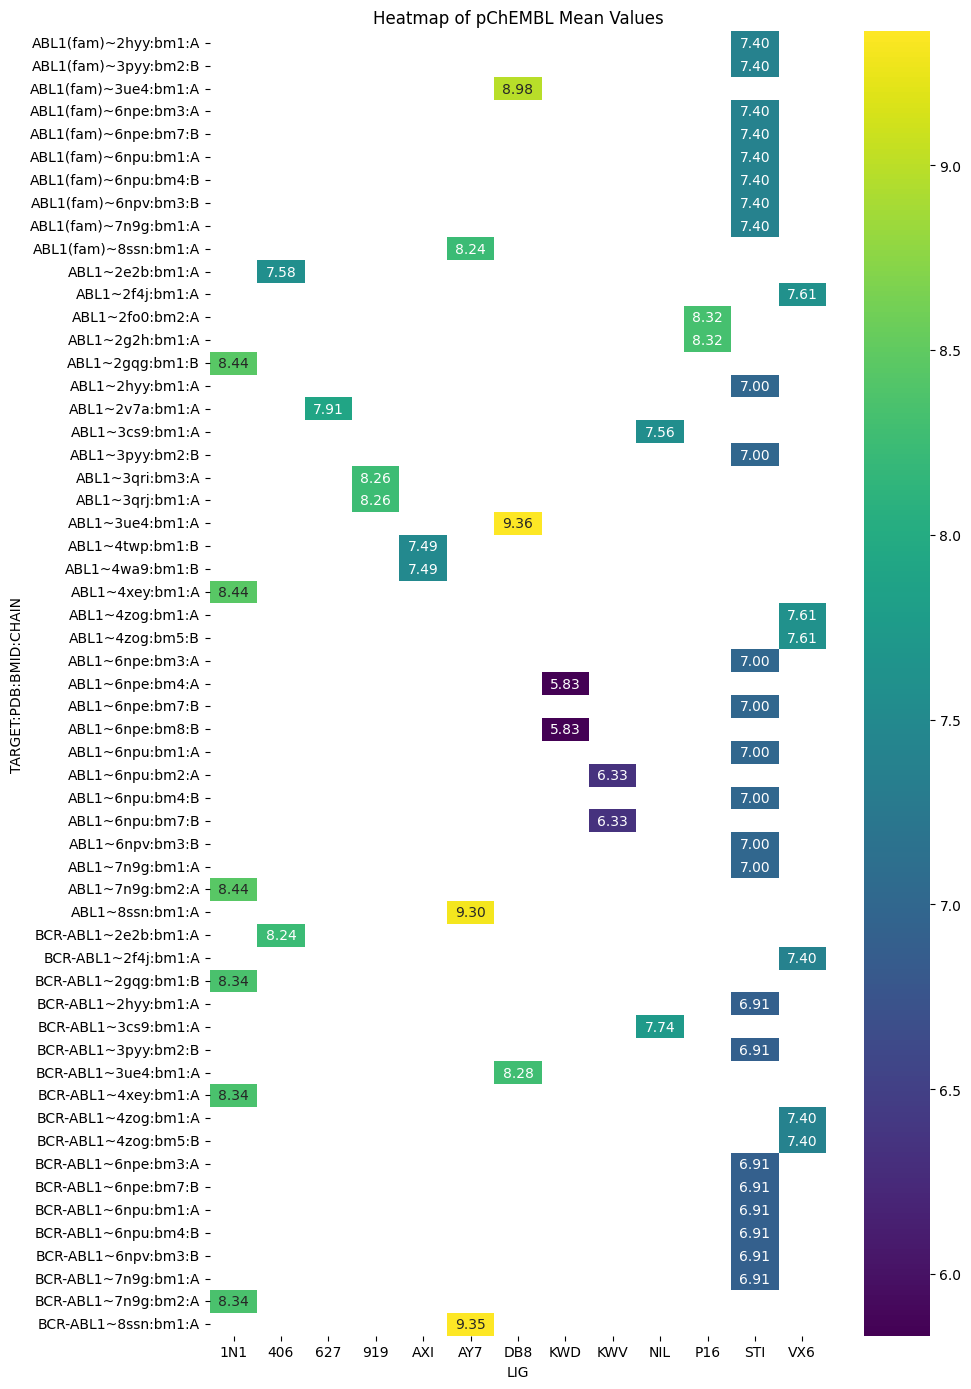

In [ ]:
# Transforming data to plot
heatmap_data = report_target.pivot(index='TARGET', columns='LIG', values='VALUE_REP') # Create a pivot table with PDB_BMID_CHAIN as index, LIG as columns, and VALUE_REP as values

# Generate the heatmap using seaborn
plt.figure(figsize=(10, 14))  # Adjust figure size as needed
sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt=".2f")  # Customize cmap and annotation as desired
plt.title('Heatmap of pChEMBL Mean Values')
plt.xlabel('LIG')
plt.ylabel('TARGET:PDB:BMID:CHAIN')
plt.tight_layout()
plt.show()

In this case, Imatinib (STI) is the drug with the most bioactivity reported in ChEMBL (you can also check the full report) with a calculated pchembl mean of 7 for ABL target. Other drugs also display high pChEMBL values for ABL. However, most of the drugs reporting high biioactivity for ABL have also a lower pCHEMBL for BCR-ABL1 fusion.

Furthermore, it is observed that Desanitinib (1N1) shows high pChEMBL towards BCR-ABL type. Desatinib is a tyrosine kinase inhibitor that's used to treat BCR-ABL-positive leukemias, including chronic myeloid leukemia (CML) and acute lymphocytic leukemia (ALL).

You can check more details in the compound [report card](https://www.ebi.ac.uk/chembl/web_components/explore/compound/CHEMBL1421).



## Part 2: Analyzing binding environment  

In this section, we will identify the ligand-binding residues for a specified PDB structure and its bound molecule using the PDBe API. In part 1, we observed that the **structures with Imatinib** (PDB ID: 2HYY, ligand ID: STI, BM_ID: bm1 ) and **Dasatinib** (PDB ID: 2GQG, ligand ID: 1N1, BM_ID: bm1) have **pChEMBL mean values** of **7.40** and **8.44**, respectively. Now, let’s examine the binding residues for these drug molecules.

Helper functions

In [ ]:
import requests, json


def get_url(url):
    """
    Makes a request to a URL. Returns a JSON of the results
    :param str url:
    :return dict:
    """
    response = requests.get(url)

    if response.status_code == 200:
        return response.json()
    else:
        print("[No data retrieved - %s] %s" % (response.status_code, response.text))

    return {}


from google.colab import data_table

# Enable extension that renders pandas dataframes into interactive displays that can be filtered, sorted, and explored dynamically.
data_table.enable_dataframe_formatter()

def make_table(my_df) :
  """
  Make interactive table in colab
  """
  return data_table.DataTable(my_df,include_index=False, num_rows_per_page=5, max_columns=2000,max_rows=100000)





Let's find the binding residues for PDB structure with Imatinib bound (PDB ID: 2HYY, ligand ID: STI, BM_ID: bm1)

In [ ]:

pdb_id='2hyy'
bm_id='bm1'

# API to get interactions for a given PDB ID and bound-molecule ID
pdb_bm_interactions_api=f'https://www.ebi.ac.uk/pdbe/graph-api/pdb/bound_molecule_interactions/{pdb_id}/{bm_id}'
data=get_url(pdb_bm_interactions_api)
# print raw data from API
print(data)

{'2hyy': [{'interactions': [{'begin': {'chain_id': 'A', 'author_residue_number': 600, 'chem_comp_id': 'STI', 'author_insertion_code': ' '}, 'end': {'chain_id': 'A', 'author_residue_number': 146, 'chem_comp_id': 'HOH', 'author_insertion_code': ' '}, 'interactions': {'atom_atom': ['vdw_clash', 'hbond', 'polar', 'vdw', 'weak_polar'], 'atom_plane': [], 'plane_plane': [], 'group_group': [], 'group_plane': []}}, {'begin': {'chain_id': 'A', 'author_residue_number': 600, 'chem_comp_id': 'STI', 'author_insertion_code': ' '}, 'end': {'chain_id': 'A', 'author_residue_number': 248, 'chem_comp_id': 'LEU', 'author_insertion_code': ' '}, 'interactions': {'atom_atom': ['hydrophobic'], 'atom_plane': ['CARBONPI'], 'plane_plane': [], 'group_group': [], 'group_plane': []}}, {'begin': {'chain_id': 'A', 'author_residue_number': 600, 'chem_comp_id': 'STI', 'author_insertion_code': ' '}, 'end': {'chain_id': 'A', 'author_residue_number': 253, 'chem_comp_id': 'TYR', 'author_insertion_code': ' '}, 'interactions'

Let's process this raw data from the PDBe API to visualise the results in a nice tabular format using pandas.

In [ ]:
import pandas as pd

def parse_interactions_to_df(data, pdb_id):
    # Initialize an empty list to store each row's information
    rows = []

    # Iterate over each interaction entry in the JSON data
    for entry in data[pdb_id][0]["interactions"]:
        begin = entry["begin"]
        end = entry["end"]
        interactions = entry["interactions"]

        # Prepare each column's data
        begin_residue = f"{begin['chain_id']}:{begin['author_residue_number']}{begin['author_insertion_code']}:{begin['chem_comp_id']}"
        end_residue = f"{end['chain_id']}:{end['author_residue_number']}{end['author_insertion_code']}:{end['chem_comp_id']}"
        atom_atom_interactions = ", ".join(interactions["atom_atom"])
        atom_plane_interactions = ", ".join(interactions["atom_plane"])
        plane_plane_interactions = ", ".join(interactions["plane_plane"])
        group_group_interactions = ", ".join(interactions["group_group"])
        group_plane_interactions = ", ".join(interactions["group_plane"])

        # Append a dictionary with row data to the list
        rows.append({
            "ligand_residue": begin_residue,
            "macromolecule_residue": end_residue,
            "atom_atom_interactions": atom_atom_interactions,
            "atom_plane_interactions": atom_plane_interactions,
            "plane_plane_interactions": plane_plane_interactions,
            "group_group_interactions": group_group_interactions,
            "group_plane_interactions": group_plane_interactions
        })

    # Convert list of dictionaries to a DataFrame
    df_interactions = pd.DataFrame(rows)
    return df_interactions

# Usage example
# Assuming 'data' is the JSON dictionary and 'pdb_id' is the relevant PDB identifier
df1_interactions = parse_interactions_to_df(data, "2hyy")


In [ ]:
print('The binding residues for PDB structure with imatinib bound (2HYY:STI):')
make_table(df1_interactions)


The binding residues for PDB structure with imatinib bound (2HYY:STI):


,ligand_residue,macromolecule_residue,atom_atom_interactions,atom_plane_interactions,plane_plane_interactions,group_group_interactions,group_plane_interactions
0,A:600 :STI,A:146 :HOH,"vdw_clash, hbond, polar, vdw, weak_polar",,,,
1,A:600 :STI,A:248 :LEU,hydrophobic,CARBONPI,,,
2,A:600 :STI,A:253 :TYR,"hydrophobic, aromatic",,"OE, EF, FE",,
3,A:600 :STI,A:256 :VAL,hydrophobic,CARBONPI,,,
4,A:600 :STI,A:269 :ALA,"hydrophobic, weak_polar",,,,
5,A:600 :STI,A:271 :LYS,hydrophobic,,,,
6,A:600 :STI,A:286 :GLU,"hbond, hydrophobic, weak_hbond, polar, vdw, we...",,,,
7,A:600 :STI,A:289 :VAL,hydrophobic,,,,
8,A:600 :STI,A:290 :MET,"hbond, hydrophobic, polar, vdw_clash","CARBONPI, METSULPHURPI",,,
9,A:600 :STI,A:293 :ILE,hydrophobic,,,,


Let's look at the PDB structure with Dasatinib (PDB ID: 2GQG, ligand ID: 1N1, BM_ID: bm1)

In [ ]:
pdb_id='2gqg'
bm_id='bm1'

# API to get interactions for a given PDB ID and bound-molecule ID
pdb_bm_interactions_api=f'https://www.ebi.ac.uk/pdbe/graph-api/pdb/bound_molecule_interactions/{pdb_id}/{bm_id}'
data2=get_url(pdb_bm_interactions_api)
df2_interactions = parse_interactions_to_df(data2, pdb_id)
print('The binding residues for PDB structure with Dasatinib (2GQG:1N1):')
make_table(df2_interactions)

The binding residues for PDB structure with Dasatinib (2GQG:1N1):


,ligand_residue,macromolecule_residue,atom_atom_interactions,atom_plane_interactions,plane_plane_interactions,group_group_interactions,group_plane_interactions
0,B:502 :1N1,B:248 :LEU,hydrophobic,CARBONPI,,,
1,B:502 :1N1,B:253 :TYR,hydrophobic,,,,
2,B:502 :1N1,B:256 :VAL,hydrophobic,,,,
3,B:502 :1N1,B:269 :ALA,"hydrophobic, vdw",CARBONPI,,,
4,B:502 :1N1,B:271 :LYS,"hydrophobic, weak_hbond, weak_polar",,,,
5,B:502 :1N1,B:286 :GLU,"hydrophobic, vdw, weak_polar",,,,
6,B:502 :1N1,B:290 :MET,hydrophobic,METSULPHURPI,,,
7,B:502 :1N1,B:299 :VAL,hydrophobic,,,,
8,B:502 :1N1,B:313 :ILE,hydrophobic,,,,
9,B:502 :1N1,B:315 :THR,"vdw_clash, hbond, hydrophobic, polar, weak_hbo...",CARBONPI,,,


In order to do large-scale binding site analysis of all the ligands bound to a given protein, please refer to our [PDBe-KB API tutorials (section 1. Ligand interactions) here.](https://github.com/PDBeurope/pdbe-notebooks/blob/main/pdbe_ligands_tutorials/PDBe_KB_API_tutorials.ipynb)

### Drug Resistance in Tyrosine Kinase Inhibitors
Drug resistance in tyrosine kinase inhibitors (TKIs) is a significant issue in treating Philadelphia chromosome-positive leukemias, especially in advanced stages. Resistance often arises from point mutations in the BCR/ABL gene, such as T315I, which hinders TKI efficacy. The T315I mutation in BCR/ABL is a "gatekeeper" mutation that confers resistance to all approved tyrosine kinase inhibitors (TKIs) except Ponatinib (https://doi.org/10.1182/blood-2019-131694). Let's look at how the T315 interacts in the structures bound with imatinib (2HYY:STI), dasatinib (2GQG:1N1) and ponatinib (3OXZ:0LI) drug molecules and understand the structural basis of drug resistance.

Let's first get the ligand binding residues for ponatinib (PDB ligand ID: 0LI) from PDB structure 3oxz.

In [ ]:
pdb_id='3oxz'
bm_id='bm1'

# API to get interactions for a given PDB ID and bound-molecule ID
pdb_bm_interactions_api=f'https://www.ebi.ac.uk/pdbe/graph-api/pdb/bound_molecule_interactions/{pdb_id}/{bm_id}'
data3=get_url(pdb_bm_interactions_api)
df3_interactions = parse_interactions_to_df(data3, pdb_id)
make_table(df3_interactions)

,ligand_residue,macromolecule_residue,atom_atom_interactions,atom_plane_interactions,plane_plane_interactions,group_group_interactions,group_plane_interactions
0,A:1 :0LI,A:13 :HOH,weak_hbond,,,,
1,A:1 :0LI,A:248 :LEU,hydrophobic,CARBONPI,,,
2,A:1 :0LI,A:253 :TYR,"hydrophobic, aromatic, vdw",,"EF, FE",,
3,A:1 :0LI,A:256 :VAL,hydrophobic,,,,
4,A:1 :0LI,A:269 :ALA,hydrophobic,,,,
5,A:1 :0LI,A:271 :LYS,"hydrophobic, vdw",,,,
6,A:1 :0LI,A:286 :GLU,"vdw_clash, hydrophobic, weak_hbond, hbond, pol...",,,,
7,A:1 :0LI,A:289 :VAL,hydrophobic,,,,
8,A:1 :0LI,A:290 :MET,"hbond, polar, vdw, hydrophobic","CARBONPI, METSULPHURPI",,,
9,A:1 :0LI,A:293 :ILE,"hydrophobic, weak_hbond, weak_polar",,,,


Let's look at how the T315 interacts in the structures bound with imatinib (2HYY:STI), dasatinib (2GQG:1N1) and ponatinib (3OXZ:0LI) drug molecules and understand the structural basis of drug resistance.

In [ ]:

# Define the list of possible target residues
target_residues = ['A:315 :THR', 'B:315 :THR']

# Filter each DataFrame for rows where end_residue matches any of the target residues
df1_match = df1_interactions[df1_interactions["macromolecule_residue"].isin(target_residues)]
df2_match = df2_interactions[df2_interactions["macromolecule_residue"].isin(target_residues)]
df3_match = df3_interactions[df3_interactions["macromolecule_residue"].isin(target_residues)]

# Concatenate the filtered DataFrames into one
combined_df = pd.concat([df1_match, df2_match, df3_match], ignore_index=True)

# Display the resulting combined DataFrame
make_table(combined_df)


,ligand_residue,macromolecule_residue,atom_atom_interactions,atom_plane_interactions,plane_plane_interactions,group_group_interactions,group_plane_interactions
0,A:600 :STI,A:315 :THR,"hbond, hydrophobic, polar, vdw_clash",CARBONPI,,,
1,B:502 :1N1,B:315 :THR,"vdw_clash, hbond, hydrophobic, polar, weak_hbo...",CARBONPI,,,
2,A:1 :0LI,A:315 :THR,hydrophobic,CARBONPI,,,


Go to PDBe entry page and visualise the binding site in 3D for these structures.
1. https://www.ebi.ac.uk/pdbe/entry/pdb/2hyy/bound/STI
2. https://www.ebi.ac.uk/pdbe/entry/pdb/2gqg/bound/1N1
3. https://www.ebi.ac.uk/pdbe/entry/pdb/3oxz/bound/0LI

For more details on how to analyse the ligand data using PDBe webpages, please refer to our [PDBe-PDBe-KB webpages tutorials here.](https://github.com/PDBeurope/pdbe-notebooks/blob/main/pdbe_ligands_tutorials/PDBe_PDBe-KB_ligands_webpages_tutorials.pdf)

The T315 residue in the BCR/ABL kinase domain plays a crucial role in drug binding by forming hydrogen bonds with tyrosine kinase inhibitors like Imatinib and Dasatinib. However, Ponatinib interacts differently, relying on weaker carbon-pi interactions rather than direct hydrogen bonding with T315. Consequently, a T315I mutation does not disrupt Ponatinib binding as significantly, which explains Ponatinib's unique effectiveness against this resistant mutation in Philadelphia chromosome-positive leukemias.

### Overall interaction patterns

PDBe-KB has now developed a novel "ligand view" to centralise small molecule data within the PDB. These ligand-centric pages, keyed on PDB ligand identifiers such as CCD, PRD, and CLC IDs, provide a comprehensive overview of each ligand's chemical, structural, interaction, and functional information.

Go to PDBe-KB ligand page for each of these ligands and check out the 'Interactions statistics' section to look at the nature of amino-acids it generally interacts with.
1. https://wwwdev.ebi.ac.uk/pdbe-srv/pdbechem/chemicalCompound/show/STI
2. https://wwwdev.ebi.ac.uk/pdbe-srv/pdbechem/chemicalCompound/show/1N1
3. https://wwwdev.ebi.ac.uk/pdbe-srv/pdbechem/chemicalCompound/show/0LI

For more details on how to analyse the ligand data using PDBe-KB ligand webpages, please refer to section 3 of our [PDBe-PDBe-KB webpages tutorials here](https://github.com/PDBeurope/pdbe-notebooks/blob/main/pdbe_ligands_tutorials/PDBe_PDBe-KB_ligands_webpages_tutorials.pdf).



## Part 3: Cross-Database analysis
#### **Goal:** Demonstrate how to use UniChem to identify common molecules across ChEMBL, CCDC, and PDBe, and explore their structural and chemical data.
#### Tasks
1. Use UniChem to identify common molecules across ChEMBL, CCDC, and PDBe.
  * Discussion: Highlight unique data features of each resource in the context of structural bioinformatics.

In [ ]:
import requests
import gzip
import io
import pandas as pd
from google.colab import data_table
from IPython.display import display, HTML

def parse_unichem_gzipped_file_to_df(file_url, col1_name, col2_name):
    """
    Function to parse the Unichem gzipped file and return a DataFrame.
    Assumes the file maps two resources (e.g., pdb to csd).

    Args:
    - file_url (str): URL of the gzipped file to parse.
    - col1_name (str): Name of the first column in the DataFrame.
    - col2_name (str): Name of the second column in the DataFrame.

    Returns:
    - df (pd.DataFrame): A DataFrame with two columns mapping the resources.
    """
    # Fetch the gzipped file from the URL
    response = requests.get(file_url)

    # Open and decompress the gzipped content
    with gzip.GzipFile(fileobj=io.BytesIO(response.content)) as gzipped_file:
        # Read the decompressed content
        content = gzipped_file.read().decode('utf-8')

    # Initialize an empty list to store rows for the DataFrame
    rows = []

    # Iterate over each line in the content, skipping the first line
    for line in content.splitlines()[1:]:
        # Split the line by tab and strip whitespace
        data = line.strip().split('\t')

        if len(data) == 2:  # Ensure there are two values (key, value)
            rows.append(data)

    # Convert the list of rows into a pandas DataFrame
    df = pd.DataFrame(rows, columns=[col1_name, col2_name])
    return df,rows

# URLs for the files to parse
unichem_pdbtocsd_file = 'https://ftp.ebi.ac.uk/pub/databases/chembl/UniChem/data/wholeSourceMapping/src_id3/src3src50.txt.gz'
unichem_chembltocsd_file = 'https://ftp.ebi.ac.uk/pub/databases/chembl/UniChem/data/wholeSourceMapping/src_id1/src1src50.txt.gz'

# Call the function for the first file (src3:pdb to src50:csd) and create a DataFrame
df_pdb_to_csd, pdb_csd_list = parse_unichem_gzipped_file_to_df(unichem_pdbtocsd_file, 'pdb_id', 'csd_id')

# Call the function for the second file (src1:chembl to src50:csd) and create a DataFrame
df_chembl_to_csd, chembl_csd_list = parse_unichem_gzipped_file_to_df(unichem_chembltocsd_file, 'chembl_id', 'csd_id')

# Merge the two DataFrames on 'csd_id' to get a combined table with pdb_id, csd_id, and chembl_id
df_combined = pd.merge(df_pdb_to_csd, df_chembl_to_csd, on='csd_id', how='outer')

# Print the merged DataFrame

data_table.enable_dataframe_formatter()
df_combined.sort_values(by='pdb_id', ascending=False, na_position='last')



,pdb_id,csd_id,chembl_id
16408,ZZV,PIWVIB,CHEMBL513189
18293,ZZS,RIHDIW,NaN
71,ZZ8,ACANAC,NaN
19072,ZYR,SEFRAW,CHEMBL539906
19890,ZWN,TAFBEH,CHEMBL451532
...,...,...,...
26388,NaN,ZZZWPU,CHEMBL3187281
26389,NaN,ZZZWPW,CHEMBL2251584
26390,NaN,ZZZWQC,CHEMBL117135
26391,NaN,ZZZZCA,CHEMBL1555953


In [ ]:
# Filter the DataFrame for rows where pdb_id, csd_id, and chembl_id are all present
df_common = df_combined.dropna()

# Print the total count of common molecules using HTML for bold formatting
display(HTML(f"There are a total of <strong>{len(df_common)} </strong> small-molecules common in PDB, CSD, and ChEMBL."))

# Display the filtered DataFrame in a table
df_common

,pdb_id,csd_id,chembl_id
10,DB8,ABEDUJ,CHEMBL288441
13,9W9,ABEGEU,CHEMBL294016
19,2A7,ABELEY,CHEMBL1738712
35,2F2,ABEWAG,CHEMBL119178
43,EGR,ABITAK,CHEMBL453196
...,...,...,...
26364,IEJ,ZZZULS,CHEMBL176892
26378,OC9,ZZZVYK,CHEMBL26215
26380,1DO,ZZZWDK,CHEMBL24722
26381,74C,ZZZWEQ,CHEMBL17564


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_common)

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Filter the DataFrame for rows where csd_id and chembl_id are both present
df_csd_chembl = df_combined[['csd_id', 'chembl_id']].dropna()

# Print the total count of common molecules using HTML for bold formatting
display(HTML(f"There are a total of <strong>{len(df_csd_chembl)} </strong> small-molecules common in CSD and ChEMBL."))

# Display the filtered DataFrame in a table
df_csd_chembl

,csd_id,chembl_id
0,ABADEO,CHEMBL2088282
1,ABADIS,CHEMBL439834
2,ABAHAQ,CHEMBL3963490
3,ABAHEU,CHEMBL284153
4,ABAHIX,CHEMBL4592073
...,...,...
26388,ZZZWPU,CHEMBL3187281
26389,ZZZWPW,CHEMBL2251584
26390,ZZZWQC,CHEMBL117135
26391,ZZZZCA,CHEMBL1555953
